In [1]:
import pandas as pd

df = pd.read_csv("stressdata_preprocessed.csv")

X = df.drop(columns=['Stress Level'])
y = df['Stress Level']

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

y_pred_lr=lr.predict(X_test)

In [11]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

y_pred_dt=dt.predict(X_test)

In [12]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

In [18]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error, accuracy_score

def evaluate_model_metrics(y_test, y_pred, is_classifier=False):
    metrics = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }
    if is_classifier:
        metrics["Accuracy"] = accuracy_score(y_test, y_pred)
    return metrics

results = {
    "Linear": evaluate_model_metrics(y_test, y_pred_lr, is_classifier=False),
    "Decision Tree": evaluate_model_metrics(y_test, y_pred_dt, is_classifier=True),
    "Random Forest": evaluate_model_metrics(y_test, y_pred_rf, is_classifier=True)
}
results

{'Linear': {'MAE': 1.3735516191537303,
  'MSE': 2.973996121310163,
  'R2': 0.4505443019651296},
 'Decision Tree': {'MAE': 1.9066666666666667,
  'MSE': 6.086666666666667,
  'R2': -0.12453195822111263,
  'Accuracy': 0.16},
 'Random Forest': {'MAE': 1.56,
  'MSE': 4.293333333333333,
  'R2': 0.20679235367535975,
  'Accuracy': 0.20333333333333334}}

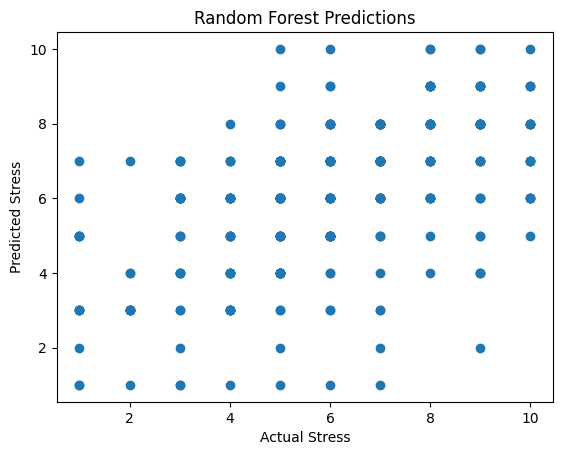

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Stress")
plt.ylabel("Predicted Stress")
plt.title("Random Forest Predictions")
plt.show()

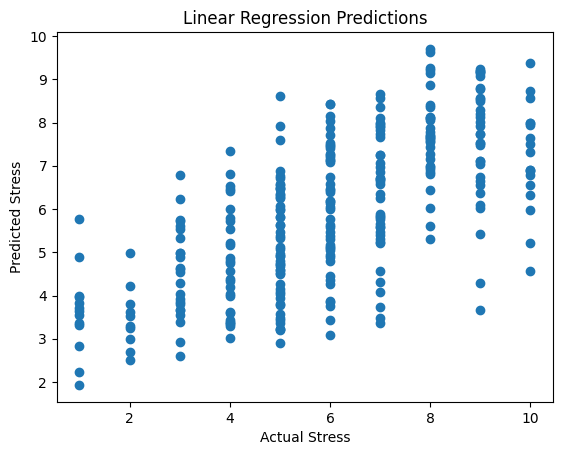

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Stress")
plt.ylabel("Predicted Stress")
plt.title("Linear Regression Predictions")
plt.show()

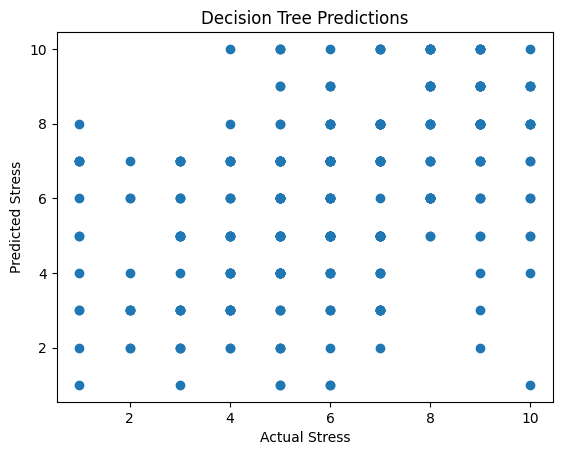

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Stress")
plt.ylabel("Predicted Stress")
plt.title("Decision Tree Predictions")
plt.show()